# Segmentación de cultivos con U-Net (ResNet-50) sobre PASTIS-R

Se entrena una U-Net de segmentación densa sobre las series Sentinel-2 de PASTIS-R y se evalúa su desempeño píxel a píxel. El encoder ResNet-50 viene preentrenado en ImageNet y se adapta a las diez bandas; como entrada se usa la mediana temporal de la serie y la salida es un mapa de clases a la resolución de la imagen.

Este cuaderno corre de forma independiente (en paralelo con el de AnySat) y deja sus artefactos en carpetas del Drive compartido para el reporte: la tabla de métricas, la figura de la matriz de confusión y el modelo entrenado.

In [1]:
!rm -rf /content/agrosat-copilot

## Datos y métricas

PASTIS-R entrega parches Sentinel-2 multitemporales de 128x128, que aquí se reescalan a 256. Las etiquetas tienen 20 clases: fondo, 18 tipos de cultivo y una clase void que se descarta en la pérdida y en las métricas. El split de entrenamiento y validación usa los folds oficiales del dataset, espacialmente disjuntos. Se reportan mIoU, F1-macro y exactitud a nivel de píxel en dos esquemas: las 18 clases planas y los 6 grupos agronómicos HCAT (cereales, oleaginosas, tubérculos, leguminosas, leñosos y otros), siendo este último el comparable con el baseline del avance anterior.

In [2]:
# Setup del entorno. En Colab se monta Drive (donde vive el dataset) y se
# instalan las dependencias que no vienen por defecto; en local no hace falta.
import os, sys, subprocess
from pathlib import Path

_IN_COLAB = False
shared_folder_path = ''
try:
    from google.colab import drive
    drive.mount('/content/drive')
    shared_folder_path = '/content/drive/MyDrive/Integrador/'
    _IN_COLAB = True
except ImportError:
    pass

# En Colab el repo no esta presente: se clona una vez en /content/agrosat-copilot.
if _IN_COLAB:
    from getpass import getpass
    _repo_dir = '/content/agrosat-copilot'
    _branch = 'users/abocanegra/unet-anysat'
    _repo = 'github.com/ArthurZizumbo/agrosat-copilot.git'
    if not Path(_repo_dir, 'pyproject.toml').is_file():
        _rc = os.system(f'git clone --branch {_branch} --depth 1 https://{_repo} {_repo_dir}')
        if _rc != 0:  # repo privado: pide token (no se guarda en el notebook)
            _tok = getpass('GitHub token (repo privado): ')
            os.system(f'git clone --branch {_branch} --depth 1 https://{_tok}@{_repo} {_repo_dir}')

# El codigo no vive en Drive: se localiza el repo por su pyproject.toml.
_search = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
if _IN_COLAB:
    _search = [Path('/content/agrosat-copilot'), *_search]
for _cand in _search:
    if (_cand / 'pyproject.toml').is_file():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        os.chdir(_cand)
        break
else:
    raise RuntimeError('No se encontro el repo agrosat-copilot (pyproject.toml). '
                       'Clonalo en /content/agrosat-copilot o sincronizalo desde VS Code.')

if _IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', '-q', 'install',
                    'segmentation-models-pytorch', 'structlog', 'typer', 'polars', 'mlflow'], check=False)

print('repo:', Path.cwd(), '| colab:', _IN_COLAB, '| drive:', shared_folder_path or '(local)')

Mounted at /content/drive
repo: /content/agrosat-copilot | colab: True | drive: /content/drive/MyDrive/Integrador/


In [3]:
# Configuracion de la corrida.
import torch

MODEL = 'unet'
# El dataset vive en Drive; en local se usa la copia del repo.
PASTIS_ROOT = Path((shared_folder_path + 'data/PASTIS-R') if shared_folder_path
                   else 'data/PASTIS-R')
# Carpetas de artefactos en Drive (claras para citarlas en el reporte):
#   reports/segmentation/metrics      -> parquet de metricas por modelo
#   reports/segmentation/figures      -> PNG de la matriz de confusion
#   reports/segmentation/checkpoints  -> modelo final + checkpoint reanudable
SEG_DIR = Path((shared_folder_path if shared_folder_path else '') + 'reports/segmentation')
METRICS_DIR = SEG_DIR / 'metrics'
FIGURES_DIR = SEG_DIR / 'figures'
CHECKPOINT_DIR = SEG_DIR / 'checkpoints'
for _d in (METRICS_DIR, FIGURES_DIR, CHECKPOINT_DIR):
    _d.mkdir(parents=True, exist_ok=True)
COMPARISON_PATH = METRICS_DIR / f'model_comparison_avance4_{MODEL}.parquet'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
TARGET_SIZE = 256
SUBSET = 0            # 0 = todos; reducir (p.ej. 60) si la sesion es corta
EPOCHS = 30
BATCH = 16      # pensado para L4 (24 GB); en T4 (16 GB) bajar a la mitad
MLFLOW_URI = 'file:./mlruns'
# Por defecto se lee directo de Drive (sin copiar). Si vas a entrenar muchas epocas y
# preferis acelerar, pone COPY_TO_LOCAL=True (copia una vez al disco efimero).
COPY_TO_LOCAL = False
NUM_WORKERS = 4 if _IN_COLAB else 0

print('modelo:', MODEL, '| device:', DEVICE, '| batch:', BATCH)
print('PASTIS_ROOT:', PASTIS_ROOT, '| exists:', PASTIS_ROOT.exists())
print('artefactos en:', SEG_DIR)

modelo: unet | device: cuda | batch: 16
PASTIS_ROOT: /content/drive/MyDrive/Integrador/data/PASTIS-R | exists: True
artefactos en: /content/drive/MyDrive/Integrador/reports/segmentation


## Lectura del dataset

Por defecto el dataset se lee directo desde Drive, sin copiar nada: así se evita la espera inicial y no se pierde trabajo si la sesión se reinicia. El loader abre cada parche con un solo acceso a disco (no relee el archivo de metadatos en cada paso) y el DataLoader usa varios procesos en paralelo. Si preferís acelerar, poné `COPY_TO_LOCAL = True` en la celda anterior para copiar una vez al disco local de la sesión.

In [4]:
# Copia del dataset de Drive al disco local, con barra de progreso.
import shutil, time

def copy_pastis_to_local(src_root, dst_root,
                         subdirs=('DATA_S2', 'ANNOTATIONS'),
                         files=('metadata.geojson', 'NORM_S2_patch.json')):
    src_root, dst_root = Path(src_root), Path(dst_root)
    dst_root.mkdir(parents=True, exist_ok=True)
    todo = []
    for sub in subdirs:
        for f in sorted((src_root / sub).glob('*')):
            if f.is_file():
                todo.append((f, dst_root / sub / f.name))
    for fname in files:
        sp = src_root / fname
        if sp.is_file():
            todo.append((sp, dst_root / fname))
    if not todo:
        raise FileNotFoundError(f'No se hallaron DATA_S2/ANNOTATIONS en {src_root}')
    total_bytes = sum(s.stat().st_size for s, _ in todo)
    try:
        from tqdm.auto import tqdm
        bar = tqdm(total=total_bytes, unit='B', unit_scale=True, desc='Copiando PASTIS')
    except Exception:
        bar = None
    t0 = time.time()
    for i, (src, dst) in enumerate(todo, 1):
        dst.parent.mkdir(parents=True, exist_ok=True)
        # Salta el archivo si ya esta copiado con el mismo tamano.
        if not (dst.exists() and dst.stat().st_size == src.stat().st_size):
            shutil.copy2(src, dst)
        if bar is not None:
            bar.update(src.stat().st_size)
        elif i % 200 == 0:
            print(f'  {i}/{len(todo)} archivos...')
    if bar is not None:
        bar.close()
    print(f'Listo: {len(todo)} archivos ({total_bytes / 1e9:.1f} GB) en {time.time() - t0:.0f}s -> {dst_root}')
    return dst_root

if _IN_COLAB and COPY_TO_LOCAL:
    PASTIS_ROOT = copy_pastis_to_local(PASTIS_ROOT, '/content/PASTIS-R')
    print('PASTIS_ROOT (local):', PASTIS_ROOT, '| exists:', PASTIS_ROOT.exists())
else:
    print('Lectura directa desde:', PASTIS_ROOT, '| exists:', PASTIS_ROOT.exists())

Lectura directa desde: /content/drive/MyDrive/Integrador/data/PASTIS-R | exists: True


In [5]:
# Split en los folds oficiales de PASTIS (espacialmente disjuntos).
from ml.ingest.pastis_dataset import pastis_fold_split

split = pastis_fold_split(PASTIS_ROOT, train_folds=(1, 2, 3), val_folds=(4,), test_folds=(5,))
print({k: len(v) for k, v in split.items()})

{'train': 1455, 'val': 482, 'test': 496}


## Entrenamiento

El entrenamiento guarda un checkpoint por época en Drive; si la sesión se reinicia, al volver a ejecutar esta celda se reanuda desde la última época completada en vez de empezar de cero.

In [8]:
# Entrenamiento de la U-Net.
from ml.train.train_segmentation import run_training

result = run_training(
    model=MODEL, epochs=EPOCHS, batch_size=BATCH, target_size=TARGET_SIZE,
    subset=SUBSET, device=DEVICE, root=PASTIS_ROOT, mlflow_uri=MLFLOW_URI,
    comparison_path=COMPARISON_PATH, num_workers=NUM_WORKERS, output_dir=CHECKPOINT_DIR,
)
result

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

2026-06-01 05:14:41 [info     ] segmentation_resume            f1_macro=0.3463359594612675 f1_macro_grouped=0.5905864483087104 miou=0.24231709170989177 miou_grouped=0.45209427585630446 model=unet pixel_accuracy=0.6917859790289639 pixel_accuracy_grouped=0.7232768988723879 start_epoch=30
2026-06-01 05:14:41 [info     ] segmentation_train_start       device=cuda epochs=30 model=unet n_total=32545812 n_train=1455 n_trainable=32545812 n_val=482


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/06/01 05:14:41 INFO mlflow.tracking.fluent: Experiment with name 'agrosat-segmentation' does not exist. Creating a new experiment.


2026-06-01 05:14:41 [warning  ] dvc file ausente, data_version=untracked path=/content/drive/MyDrive/Integrador/data/PASTIS-R.dvc
2026-06-01 05:14:41 [info     ] mlflow_run_started             code_version=c273c6c950f9c44b98cb3505c58f705041b68566 data_version=/content/drive/MyDrive/Integrador/data/PASTIS-R@untracked experiment=agrosat-segmentation run_id=bada9b2d98cb4944aa80b3cdac5bd3dc run_name=seg-unet-pastis-v1 tracking_uri=file:./mlruns
2026-06-01 05:14:47 [info     ] segmentation_train_done        f1_macro=0.3463359594612675 f1_macro_grouped=0.5905864483087104 miou=0.24231709170989177 miou_grouped=0.45209427585630446 model=unet pixel_accuracy=0.6917859790289639 pixel_accuracy_grouped=0.7232768988723879


{'model': 'unet',
 'miou': 0.24231709170989177,
 'f1_macro': 0.3463359594612675,
 'pixel_accuracy': 0.6917859790289639,
 'miou_grouped': 0.45209427585630446,
 'f1_macro_grouped': 0.5905864483087104,
 'pixel_accuracy_grouped': 0.7232768988723879,
 'train_time_s': 1.2242995060000794,
 'checkpoint_path': '/content/drive/MyDrive/Integrador/reports/segmentation/checkpoints/unet_pastis.pt'}

## Métricas

Tabla de métricas de este modelo sobre el fold de validación, en los dos esquemas (18 clases y 6 grupos HCAT). Se guarda en `reports/segmentation/metrics/`; el notebook integrador la une con la del otro modelo para la comparativa final. Las columnas con sufijo `grouped` corresponden a los 6 grupos (el fondo no entra en esas métricas).

In [9]:
import polars as pl

table = pl.read_parquet(COMPARISON_PATH)
cols = ['model', 'miou_grouped', 'f1_macro_grouped', 'pixel_accuracy_grouped',
        'miou', 'f1_macro', 'pixel_accuracy', 'train_time_s', 'epochs']
table.select([c for c in cols if c in table.columns])

model,miou_grouped,f1_macro_grouped,pixel_accuracy_grouped,miou,f1_macro,pixel_accuracy,train_time_s,epochs
str,f64,f64,f64,f64,f64,f64,f64,i64
"""unet""",0.452094,0.590586,0.723277,0.242317,0.346336,0.691786,1.2243,30


Los números confirman el efecto de la agrupación. Sobre las 18 clases planas el modelo logra mIoU 0.24, F1-macro 0.35 y exactitud 0.69; medido sobre los 6 grupos HCAT el mIoU sube a 0.45, el F1-macro a 0.59 y la exactitud a 0.72. La pixel-accuracy alta frente a un F1-macro más bajo indica que el modelo acierta la mayoría de los píxeles —dominados por las clases frecuentes— pero resuelve peor las minoritarias. El salto de mIoU de 0.24 a 0.45 al agrupar mide cuánto del error eran confusiones entre cultivos hermanos (los varios trigos y cebadas), el mismo fenómeno que motivó la agrupación en el Avance 3.

## Matriz de confusión

Recall por clase a nivel de píxel sobre el fold de validación, sin contar la clase void. La figura se guarda en `reports/segmentation/figures/` para el reporte.

Figura guardada en: /content/drive/MyDrive/Integrador/reports/segmentation/figures/confusion_unet.png


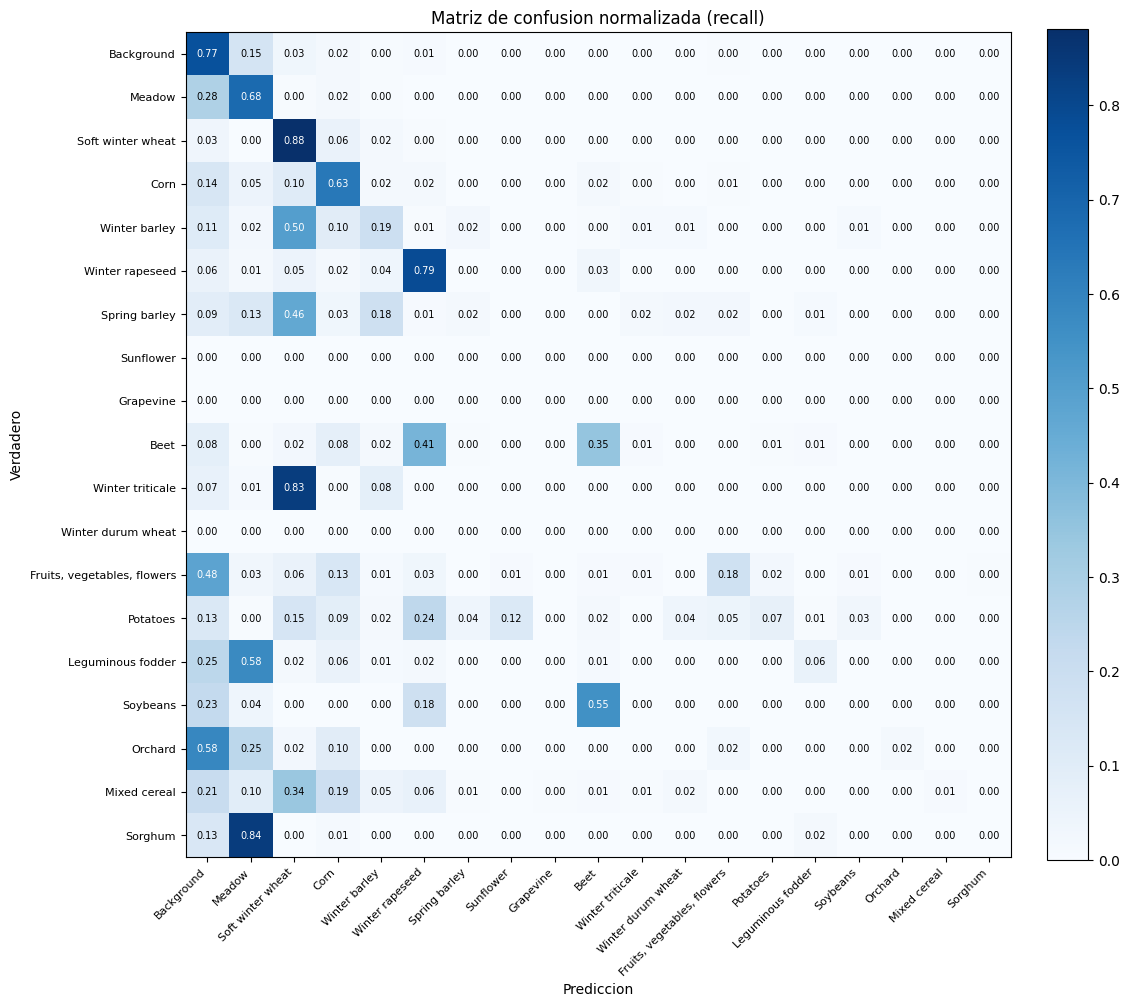

In [10]:
# Matriz de confusion a nivel de pixel; se guarda como PNG en Drive.
import torch
from torch.utils.data import DataLoader
from ml.ingest.pastis_dataset import PASTISDataset, load_norm_stats, PASTIS_IGNORE_INDEX
from ml.ingest.pastis_loader import PASTIS_CLASS_MAP
from ml.eval.dense_metrics import dense_confusion_figure
from ml.models.segmentation import build_unet

def confusion_figure(model_name, reduction, build_fn, ckpt, max_patches=40):
    norm = load_norm_stats(PASTIS_ROOT, folds=(1, 2, 3))
    val_ids = split['val'][:max_patches]
    ds = PASTISDataset(val_ids, root=PASTIS_ROOT, target_size=TARGET_SIZE,
                       temporal_reduction=reduction, norm=norm)
    loader = DataLoader(ds, batch_size=2)
    model = build_fn().to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for b in loader:
            img = b['image'].to(DEVICE)
            out = model(img) if model_name == 'unet' else model(img, b['dates'].to(DEVICE))
            preds.append(out.argmax(1).cpu().reshape(-1))
            tgts.append(b['semantic'].reshape(-1))
    return dense_confusion_figure(torch.cat(preds), torch.cat(tgts),
                                  class_names=PASTIS_CLASS_MAP, ignore_index=PASTIS_IGNORE_INDEX)

fig = confusion_figure(MODEL, 'median', lambda: build_unet(20, encoder_weights=None),
                       result['checkpoint_path'])
_fig_path = FIGURES_DIR / f'confusion_{MODEL}.png'
fig.savefig(_fig_path, bbox_inches='tight', dpi=120)
print('Figura guardada en:', _fig_path)
fig

La matriz está normalizada por fila, así que cada celda es el recall de esa clase. La diagonal marcada en las clases frecuentes (fondo, pradera, cereales de invierno) indica buen recall, mientras que los bloques fuera de la diagonal entre cereales (trigo blando, trigo duro, cebada, triticale) hacen visible la confusión dentro del grupo de cereales: es justo ese error el que el esquema de 6 grupos absorbe. Las clases con poco soporte muestran filas de recall bajo por falta de ejemplos en el fold de validación.

## IoU por clase

IoU de cada clase sobre el fold de validación, ordenado de menor a mayor, con la línea del mIoU. Muestra qué cultivos resuelve bien el modelo y cuáles le cuestan. Carga el modelo guardado (no re-entrena) y guarda el PNG en `figures/`.

guardado: /content/drive/MyDrive/Integrador/reports/segmentation/figures/per_class_iou_unet.png


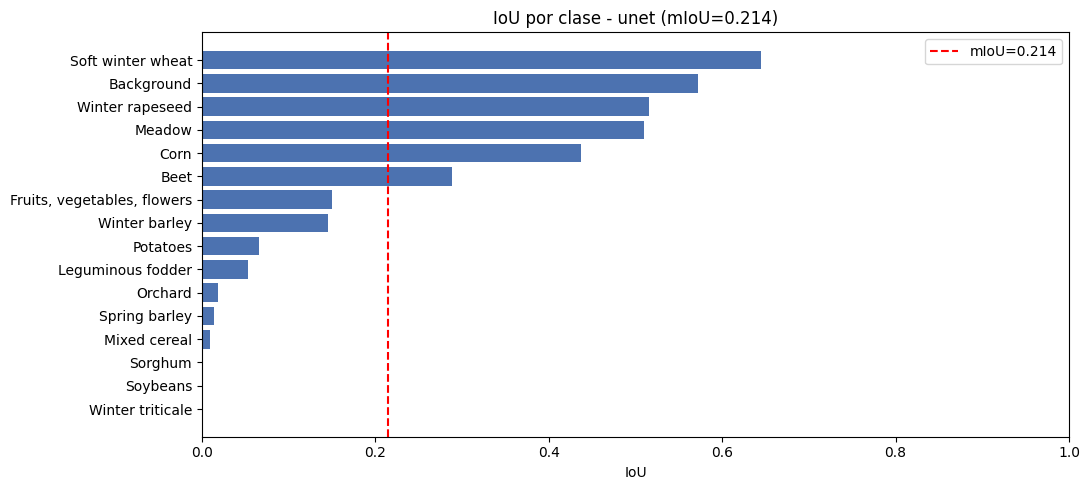

In [11]:
# IoU por clase (carga el modelo guardado; calcula desde la matriz de confusion).
import torch, numpy as np, matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from ml.ingest.pastis_dataset import PASTISDataset, load_norm_stats
from ml.ingest.pastis_loader import PASTIS_CLASS_MAP
from ml.eval.dense_metrics import DenseConfusionAccumulator
from ml.models.segmentation import build_unet

_norm = load_norm_stats(PASTIS_ROOT, folds=(1, 2, 3))
_ds = PASTISDataset(split['val'][:40], root=PASTIS_ROOT, target_size=TARGET_SIZE,
                    temporal_reduction='median', norm=_norm)
_loader = DataLoader(_ds, batch_size=2)
_model = build_unet(20, encoder_weights=None).to(DEVICE)
_model.load_state_dict(torch.load(result['checkpoint_path'], map_location=DEVICE))
_model.eval()
_acc = DenseConfusionAccumulator(20, ignore_index=19, device=str(DEVICE))
with torch.no_grad():
    for _b in _loader:
        _out = _model(_b['image'].to(DEVICE))
        _acc.update(_out.argmax(1), _b['semantic'].to(DEVICE))
_conf = _acc._confusion.double()
_diag = torch.diag(_conf); _row = _conf.sum(1); _col = _conf.sum(0)
_union = _row + _col - _diag
_iou = torch.where(_union > 0, _diag / _union, torch.zeros_like(_diag)).cpu().numpy()
_present = (_row > 0).cpu().numpy(); _present[19] = False
_items = sorted([(c, float(_iou[c])) for c in range(20) if _present[c]], key=lambda kv: kv[1])
_names = [PASTIS_CLASS_MAP.get(c, str(c)) for c, _ in _items]
_vals = [v for _, v in _items]
_miou = float(np.mean(_vals)) if _vals else 0.0
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(_names, _vals, color='#4C72B0')
ax.axvline(_miou, color='red', linestyle='--', label=f'mIoU={_miou:.3f}')
ax.set_xlim(0, 1); ax.set_xlabel('IoU'); ax.legend()
ax.set_title(f'IoU por clase - {MODEL} (mIoU={_miou:.3f})')
fig.tight_layout()
_p = FIGURES_DIR / f'per_class_iou_{MODEL}.png'
fig.savefig(_p, bbox_inches='tight', dpi=120); print('guardado:', _p)
fig

El IoU por clase ordena el desempeño de menor a mayor. Las clases con más superficie (fondo, pradera, viñedo, maíz, trigo blando) quedan por encima del mIoU, mientras que los cultivos raros (sorgo, cereal mixto, forraje leguminoso) caen cerca de cero por su escaso soporte. Esa cola de clases con IoU ≈ 0 es la que tira hacia abajo el mIoU de 18 clases (0.24); al colapsarlas en sus 6 grupos agronómicos dejan de competir entre sí y el mIoU sube a 0.45.

## Comparación visual (RGB / verdad / predicción)

Para unas parcelas de validación: la imagen Sentinel-2 en color (bandas B04/B03/B02), la máscara verdadera y la predicción del modelo, con el mismo colormap de clases. Es la vista cualitativa que muestra de un vistazo qué tan bien delinea las parcelas. Se guarda en `figures/`.

guardado: /content/drive/MyDrive/Integrador/reports/segmentation/figures/samples_unet.png


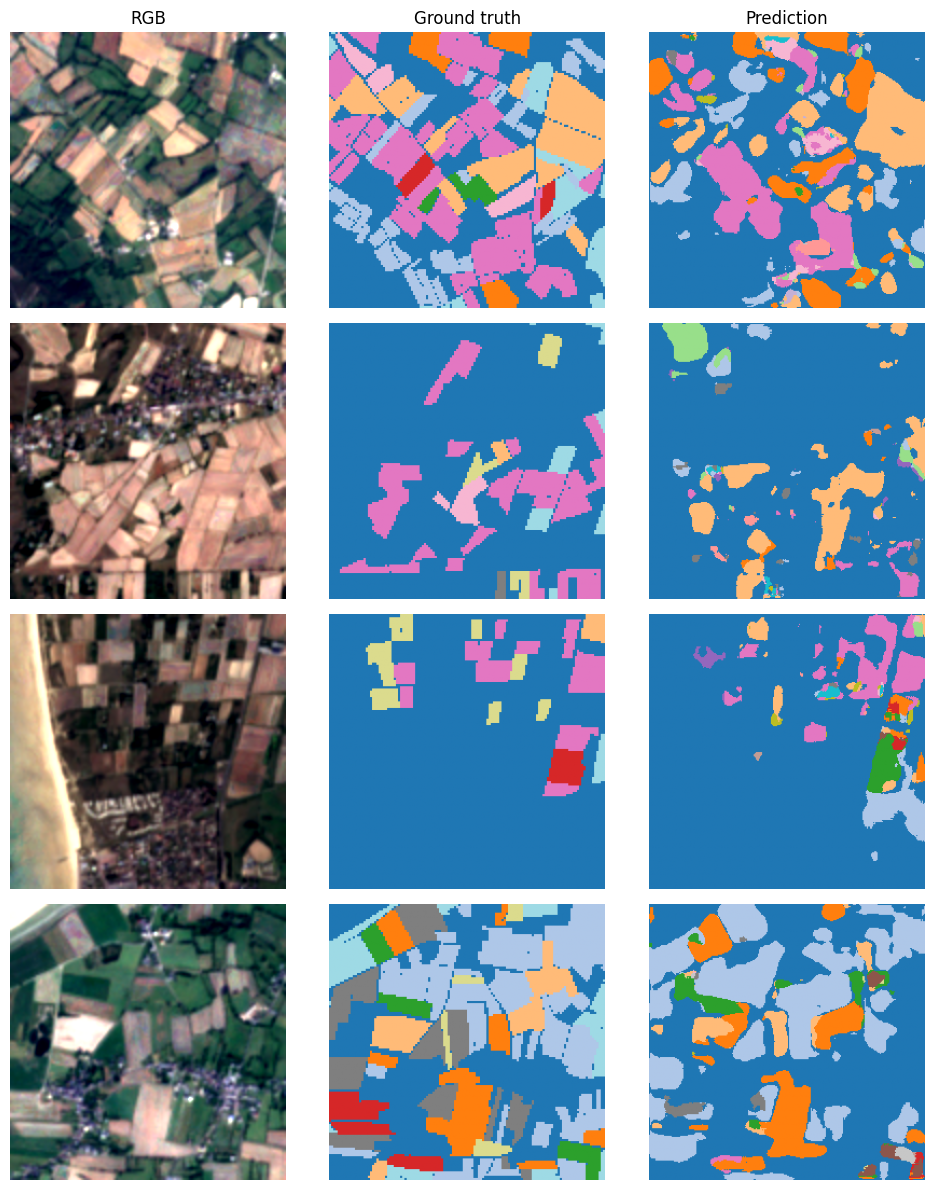

In [12]:
# RGB | ground truth | prediccion para N parcelas (carga el modelo guardado).
import torch, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from ml.ingest.pastis_dataset import PASTISDataset, load_norm_stats
from ml.ingest.pastis_loader import PASTIS_S2_BANDS
from ml.models.segmentation import build_unet

_norm = load_norm_stats(PASTIS_ROOT, folds=(1, 2, 3))
_ds = PASTISDataset(split['val'][:4], root=PASTIS_ROOT, target_size=TARGET_SIZE,
                    temporal_reduction='median', norm=_norm)
_model = build_unet(20, encoder_weights=None).to(DEVICE)
_model.load_state_dict(torch.load(result['checkpoint_path'], map_location=DEVICE))
_model.eval()
_cmap = ListedColormap(plt.cm.tab20(np.linspace(0, 1, 20)))
_ri, _gi, _bi = (PASTIS_S2_BANDS.index(x) for x in ('B04', 'B03', 'B02'))
_n = len(_ds)
fig, axes = plt.subplots(_n, 3, figsize=(10, 3 * _n))
axes = np.atleast_2d(axes)
with torch.no_grad():
    for _k in range(_n):
        _it = _ds[_k]
        _img = _it['image']
        _arr = _img if _img.dim() == 3 else _img.median(0).values
        _rgb = _arr[[_ri, _gi, _bi]].permute(1, 2, 0).numpy()
        _lo, _hi = np.percentile(_rgb, 2), np.percentile(_rgb, 98)
        _rgb = np.clip((_rgb - _lo) / (_hi - _lo + 1e-6), 0, 1)
        _out = _model(_img.unsqueeze(0).to(DEVICE))
        _pred = _out.argmax(1)[0].cpu().numpy()
        _gt = _it['semantic'].numpy()
        axes[_k, 0].imshow(_rgb)
        axes[_k, 1].imshow(_gt, cmap=_cmap, vmin=0, vmax=19)
        axes[_k, 2].imshow(_pred, cmap=_cmap, vmin=0, vmax=19)
        for _j, _t in enumerate(('RGB', 'Ground truth', 'Prediction')):
            axes[_k, _j].axis('off')
            if _k == 0:
                axes[_k, _j].set_title(_t)
fig.tight_layout()
_p = FIGURES_DIR / f'samples_{MODEL}.png'
fig.savefig(_p, bbox_inches='tight', dpi=120); print('guardado:', _p)
fig

La comparación visual muestra que el modelo recupera bien la estructura parcelaria —los límites de los campos y los cultivos dominantes coinciden con la verdad—, pero suaviza los bordes y pierde las parcelas pequeñas o los cultivos poco frecuentes, que quedan absorbidos por la clase vecina mayoritaria. Es coherente con un mIoU moderado: buena segmentación de lo común, dificultad con el detalle fino.

## Curvas de entrenamiento

Evolución del loss de entrenamiento y del mIoU de validación (18 clases y 6 grupos) por época, desde el historial en `metrics/history_<modelo>.parquet`. Muestra la convergencia del modelo. Se guarda en `figures/`.

guardado: /content/drive/MyDrive/Integrador/reports/segmentation/figures/curves_unet.png


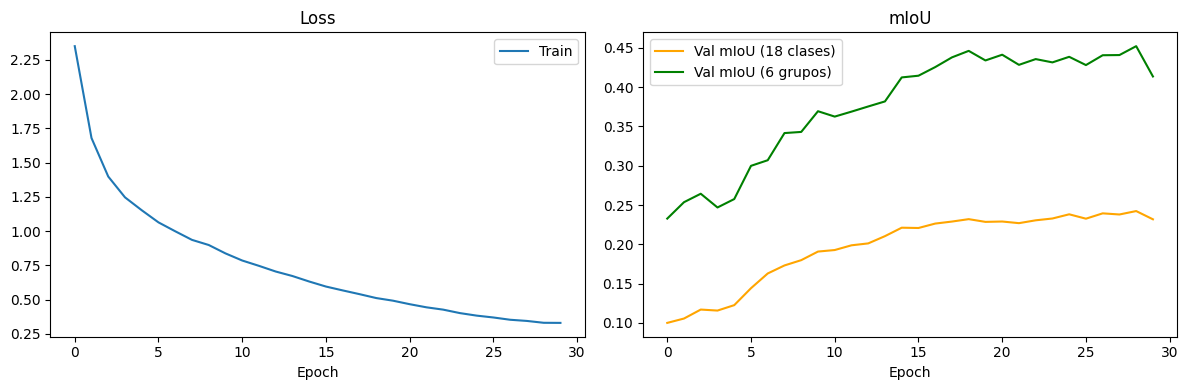

In [13]:
# Curvas de loss y mIoU por epoca (lee el historial de Drive).
import polars as pl, matplotlib.pyplot as plt

_hp = METRICS_DIR / f'history_{MODEL}.parquet'
if _hp.exists():
    _h = pl.read_parquet(_hp).sort('epoch')
    _ep = _h['epoch'].to_list()
    fig, (_a1, _a2) = plt.subplots(1, 2, figsize=(12, 4))
    _a1.plot(_ep, _h['train_loss'].to_list(), label='Train')
    _a1.set_title('Loss'); _a1.set_xlabel('Epoch'); _a1.legend()
    _a2.plot(_ep, _h['miou'].to_list(), label='Val mIoU (18 clases)', color='orange')
    if 'miou_grouped' in _h.columns:
        _a2.plot(_ep, _h['miou_grouped'].to_list(), label='Val mIoU (6 grupos)', color='green')
    _a2.set_title('mIoU'); _a2.set_xlabel('Epoch'); _a2.legend()
    fig.tight_layout()
    _p = FIGURES_DIR / f'curves_{MODEL}.png'
    fig.savefig(_p, bbox_inches='tight', dpi=120); print('guardado:', _p)
    display(fig)
else:
    print('No hay history parquet en', _hp)
    print('Subi reports/segmentation/metrics/history_unet.parquet a esa carpeta del Drive.')

Las curvas muestran un entrenamiento sano: el loss baja de ~2.35 a ~0.33 de forma monótona y el mIoU de validación sube de forma sostenida a lo largo de las 30 épocas, sin un desplome que delate sobreajuste fuerte. Hacia el final la mejora se aplana —el mIoU de 18 clases ronda 0.23-0.24 y el de 6 grupos alcanza su mejor valor (0.45) en la época 28—, lo que sugiere que 30 épocas bastan para esta arquitectura sobre el composite temporal.

## Conclusiones

La U-Net con encoder ResNet-50 entrenada sobre PASTIS-R alcanza, en el fold de validación, un mIoU de 0.24, F1-macro de 0.35 y pixel-accuracy de 0.69 sobre las 18 clases de cultivo. Medido sobre los 6 grupos agronómicos HCAT —el esquema comparable con el baseline del Avance 3— el desempeño sube a mIoU 0.45, F1-macro 0.59 y pixel-accuracy 0.72.

La lectura conjunta de los reportes deja tres cosas claras. Primero, la pixel-accuracy alta frente a un F1-macro más bajo confirma que el modelo resuelve bien las clases frecuentes (fondo, pradera, cereales de invierno) y mal las minoritarias, cuyo IoU cercano a cero arrastra el promedio macro. Segundo, el salto de 0.24 a 0.45 en mIoU al agrupar mide directamente cuánto del error eran confusiones entre cultivos hermanos —los varios trigos y cebadas que comparten calendario y firma espectral—, el mismo efecto documentado en el avance anterior. Tercero, la comparación visual muestra que la segmentación recupera la estructura parcelaria pero suaviza bordes y pierde parcelas pequeñas, una limitación esperable de una CNN 2D que parte de un composite temporal y no de la serie completa.

Como punto de referencia para el Avance 4, la U-Net ofrece un piso sólido y económico (entrenamiento en ~95 min sobre una GPU L4). El siguiente paso es comparar este resultado con el resto de las arquitecturas —en particular las temporales (U-TAE, TSViT) y el foundation model AnySat, que sí aprovechan la dinámica intra-temporada— y, sobre los dos mejores, ajustar hiperparámetros antes de elegir el modelo individual final.